### Modeling the joint probability of seeing the aurora, given the Aurora activity and environmental conditions:

$I$. **Probability of Aurora Activity**

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import folium
from folium.plugins import MarkerCluster
import seaborn as sns
import missingno as msno
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve, f1_score, average_precision_score,fbeta_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit, StratifiedKFold
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

In [226]:
df = pd.read_csv("aurora_dataset_clean.csv")
print(f"Number of rows: {len(df)}")
with pd.option_context('display.max_columns', None):
    display(df.head())

## to suppress `moon_phase` and `moon_darkness` multicollinearity, we define `lunar_sky_glare` which assess the skylight pollution
df['lunar_sky_glare'] = df['moon_phase'] * (1.0 - df['moon_darkness'])

# This preserves the continuous nature of the 24-hour day/night cycle
if 'mlt' in df.columns:
    df['mlt_sin'] = np.sin(2 * np.pi * df['mlt'] / 24.0)
    df['mlt_cos'] = np.cos(2 * np.pi * df['mlt'] / 24.0)
 
## add for mlon
if 'mlon' in df.columns:
    df['mlon_sin'] = np.sin(2 * np.pi * df['mlon'] / 360.0)
    df['mlon_cos'] = np.cos(2 * np.pi * df['mlon'] / 360.0)


Number of rows: 22280


,raw_row_num,obs_id,activities_id,height_id,sky_id,observer_id,timestamp,address_country,address_state,location,see_aurora,sky_other,time_start,time_end,on_going,height_other,activities_other,colors_other,types_other,comment,image,latitude,longitude,colors,types,image_url,small_image_url,redact_row,pii_redacted,duration,mlat,mlon,mlt,utc_dt,date,hour,minute,second,kp_3hr_bucket,kp,bz_gsm,sigma_bz_gsm,solar_wind_speed,ap,Ap,cloud_cover,visibility,moon_phase,moon_darkness,sun_elevation_utc,astronomical_dark_utc,sun_elevation_localtime,astronomical_dark_localtime
0,1,7372c36fe0c7,NaN,NaN,NaN,117.0,2014-10-01 08:21:34.818216+00:00,United Arab Emirates,Dubai,SRID=4326;POINT (55.154846755193745 25.0416718...,False,NaN,2014-10-01 08:15:00+00:00,2014-10-01 08:30:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,25.041672,55.154847,NaN,NaN,NaN,NaN,False,False,0.25,19.985358,128.137506,12.129542,2014-10-01 08:21:34.818216+00:00,2014-10-01,8,21,34,2,2.7,-1.466667,1.200000,383.0,12.0,10.625,0.0,-1,0.252,0.497,61.599046,False,28.114312,False
1,3,07c100d1ef09,NaN,NaN,clea,NaN,2014-10-02 13:47:29.552583+00:00,United States,NM,SRID=4326;POINT (-106.31864826448822 35.874131...,False,NaN,2014-10-02 13:45:00+00:00,2014-10-02 14:00:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,35.874132,-106.318648,NaN,NaN,NaN,NaN,False,False,0.25,44.155324,-39.100305,6.438991,2014-10-02 13:47:29.552583+00:00,2014-10-02,13,47,29,4,1.7,-0.966667,1.566667,376.0,6.0,6.750,1.0,-1,0.286,0.429,8.568126,False,42.357447,False
2,6,90f6d683296b,quie,n,NaN,140.0,2014-10-08 18:09:23.114761+00:00,United States,NM,SRID=4326;POINT (-106.0875978020242 35.9777940...,True,NaN,2014-10-08 18:00:00+00:00,2014-10-08 18:15:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,35.977794,-106.087598,"red, whit",arcs,NaN,NaN,False,False,0.25,44.298471,-38.831876,10.782292,2014-10-08 18:09:23.114761+00:00,2014-10-08,18,9,23,6,2.0,-5.200000,1.000000,349.0,7.0,7.625,99.0,-1,0.489,0.023,46.815086,False,-7.130364,False
3,7,e6ffd03f4085,very,n45,NaN,141.0,2014-10-08 18:11:38.395952+00:00,United States,NM,SRID=4326;POINT (-106.33536318032095 35.858267...,True,NaN,2014-10-08 18:00:00+00:00,2014-10-08 18:15:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,35.858267,-106.335363,gree,"glow, patc",NaN,NaN,False,False,0.25,44.136071,-39.115849,10.763361,2014-10-08 18:11:38.395952+00:00,2014-10-08,18,11,38,6,2.0,-5.200000,1.000000,349.0,7.0,7.625,99.0,-1,0.489,0.023,46.997034,False,-7.382139,False
4,8,a67afd419547,acti,over,NaN,141.0,2014-10-08 18:15:51.473713+00:00,United States,NM,SRID=4326;POINT (-106.3362134605038 35.8694066...,True,NaN,2014-10-08 18:00:00+00:00,2014-10-08 18:15:00+00:00,True,NaN,NaN,NaN,NaN,NaN,False,35.869407,-106.336213,"whit, gree, pink","arcs, glow",NaN,NaN,False,False,0.25,44.147181,-39.118361,10.763193,2014-10-08 18:15:51.473713+00:00,2014-10-08,18,15,51,6,2.0,-5.200000,1.000000,349.0,7.0,7.625,99.0,-1,0.489,0.023,47.196692,False,-8.241071,False


In [227]:
## remove the rows with solar_wind_speed == 9999
df = df[df['solar_wind_speed'] != 9999]

In [228]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed').dt.tz_convert('UTC')
df = df.sort_values('timestamp').reset_index(drop=True)
df['is_aurora_active'] = df['activities_id'].notna().astype(int)
df['is_aurora_seen'] = df['see_aurora'].astype(int)
print(df['is_aurora_active'].value_counts())
print(df['is_aurora_seen'].value_counts())

is_aurora_active
1    14129
0     8027
Name: count, dtype: int64
is_aurora_seen
1    16268
0     5888
Name: count, dtype: int64


In [229]:
# Identify the paradox mask, where reported seen auroras, are marked as aurora inactive
paradox_mask = (df['is_aurora_seen'] == 1) & (df['is_aurora_active'] == 0)
print(f"Dropping {paradox_mask.sum()/len(df):.2%} paradox rows from the dataset...")

# Keep only the rows that do NOT match the paradox condition
df = df[~paradox_mask].reset_index(drop=True)

Dropping 9.65% paradox rows from the dataset...


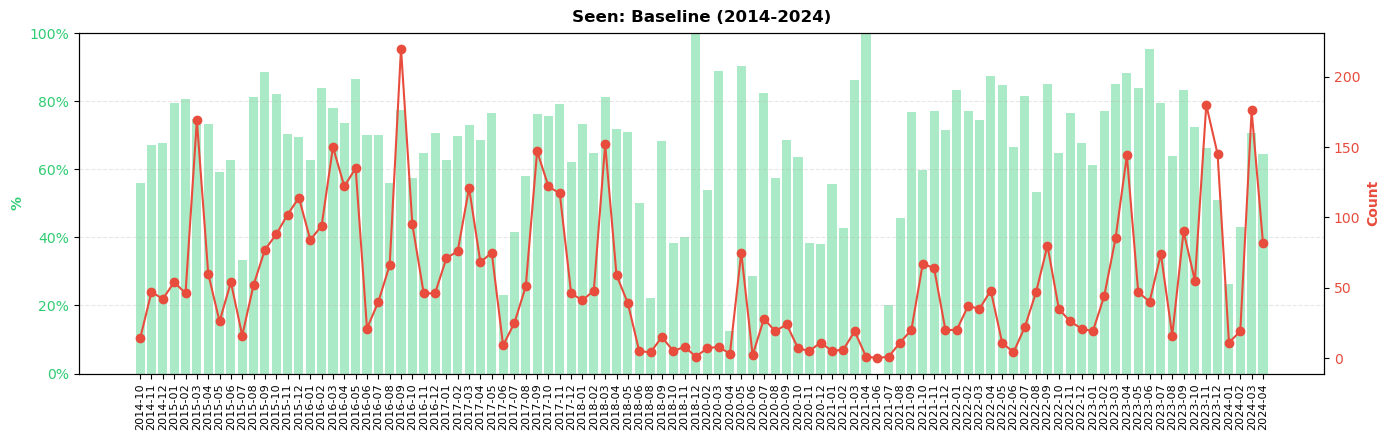

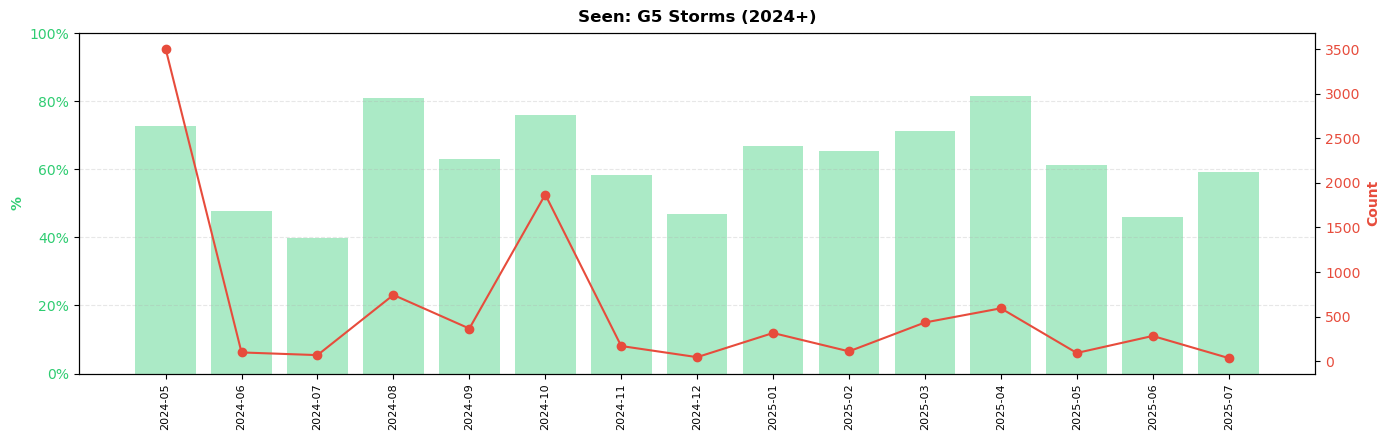

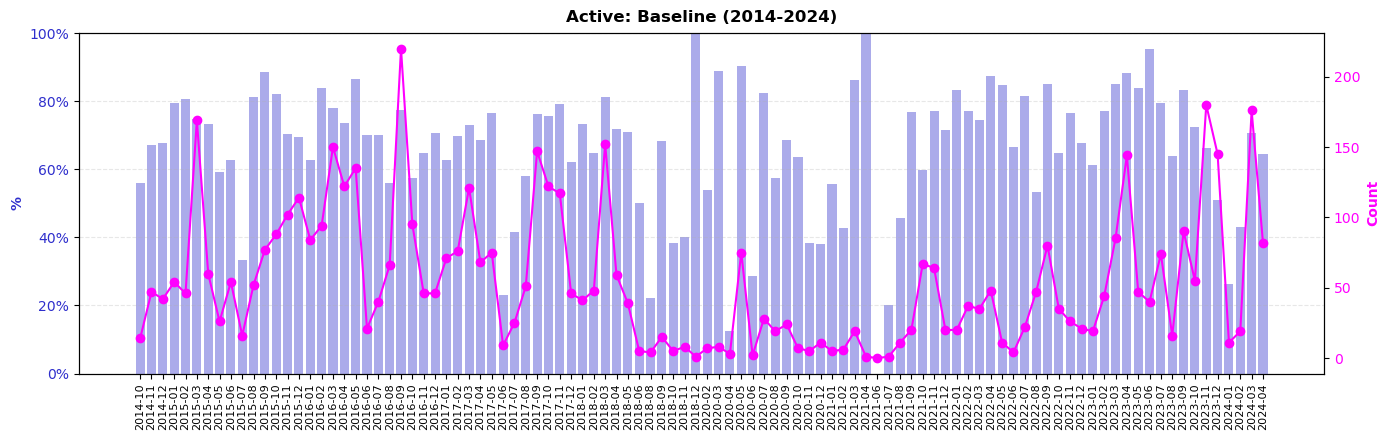

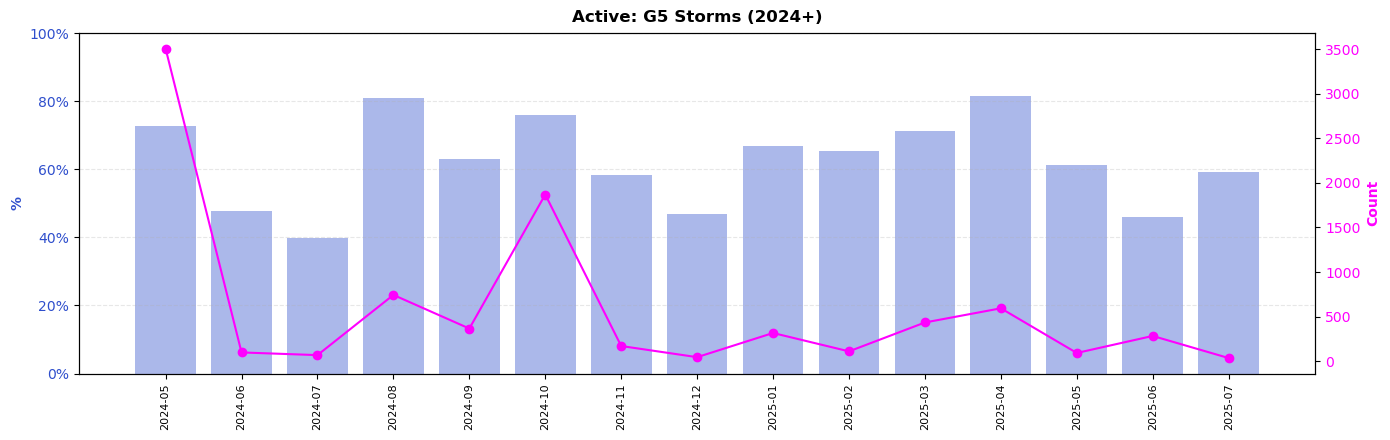

In [230]:
os.makedirs("output", exist_ok=True)

df['year_month'] = pd.to_datetime(df['utc_dt'], format='mixed').dt.tz_localize(None).dt.to_period('M').astype(str)

def df_seg(df, feat):
    monthly_stats = df.groupby('year_month')[feat].agg(['sum', 'mean']).reset_index()
    monthly_stats['percentage'] = monthly_stats['mean'] * 100
    pre_anomaly = monthly_stats[monthly_stats['year_month'] < '2024-05']
    post_anomaly = monthly_stats[monthly_stats['year_month'] >= '2024-05']      
    return pre_anomaly, post_anomaly

pre_anomaly_activity, post_anomaly_activity = df_seg(df, 'is_aurora_active')
pre_anomaly_seen, post_anomaly_seen = df_seg(df, 'is_aurora_seen')

configs = [
    (pre_anomaly_seen, "Seen: Baseline (2014-2024)", "#2ecc71", "#e74c3c"),
    (post_anomaly_seen, "Seen: G5 Storms (2024+)", "#2ecc71", "#e74c3c"),
    (pre_anomaly_activity, "Active: Baseline (2014-2024)", "#2e2ecc", 'magenta'),
    (post_anomaly_activity, "Active: G5 Storms (2024+)", "#2e4ecc", 'magenta')
]

for data, title, c1, c2 in configs:
    fig, ax = plt.subplots(figsize=(14, 4.5))
    
    # Percentage Bars
    ax.bar(data.index, data['percentage'], color=c1, alpha=0.4)
    ax.set_ylabel('%', color=c1, fontweight='bold')
    ax.tick_params(axis='y', labelcolor=c1)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter())
    
    # Count Lines
    ax_r = ax.twinx()
    ax_r.plot(data.index, data['sum'], marker='o', color=c2, linewidth=1.5)
    ax_r.set_ylabel('Count', color=c2, fontweight='bold')
    ax_r.tick_params(axis='y', labelcolor=c2)
    
    ax.set_xticks(data.index)
    ax.set_xticklabels(data['year_month'].values, rotation=90, fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_title(title, fontweight='bold', pad=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join("output", f"{title.replace(' ', '_').replace(':', '_')}.png"), dpi=300, bbox_inches='tight')
    plt.show()


In [231]:
features_phase1 = ['mlat', 'mlon_sin', 'mlon_cos', 'mlt_sin', 'mlt_cos', 'kp', 'bz_gsm', 'sigma_bz_gsm', 'solar_wind_speed']
df_skim = df.dropna(subset=features_phase1).copy()
df_skim['utc_dt'] = pd.to_datetime(df_skim['utc_dt'], format='mixed')
df_skim = df_skim.sort_values(by='utc_dt').reset_index(drop=True)

df_skim[features_phase1].info()

<class 'pandas.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mlat              19999 non-null  float64
 1   mlon_sin          19999 non-null  float64
 2   mlon_cos          19999 non-null  float64
 3   mlt_sin           19999 non-null  float64
 4   mlt_cos           19999 non-null  float64
 5   kp                19999 non-null  float64
 6   bz_gsm            19999 non-null  float64
 7   sigma_bz_gsm      19999 non-null  float64
 8   solar_wind_speed  19999 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [232]:
tscv_p1 = TimeSeriesSplit(n_splits=5)

p_activity = np.full(len(df_skim), np.nan)
final_preds = np.full(len(df_skim), np.nan)
valid_test_indices = []

for fold, (train_idx, test_idx) in enumerate(tscv_p1.split(df_skim), 1):
    # re-split train data (80% train, 20% val)
    val_size = int(len(train_idx) * 0.2)
    if val_size < 15:
        val_size = min(15, len(train_idx) // 2)
           
    train_tr_idx = train_idx[:-val_size]
    train_val_idx = train_idx[-val_size:]
    
    X1_train_tr = df_skim.iloc[train_tr_idx][features_phase1]
    y1_train_tr = df_skim.iloc[train_tr_idx]['is_aurora_active']
    
    X1_train_val = df_skim.iloc[train_val_idx][features_phase1]
    y1_train_val = df_skim.iloc[train_val_idx]['is_aurora_active']
    
    X1_test = df_skim.iloc[test_idx][features_phase1]
    y1_test = df_skim.iloc[test_idx]['is_aurora_active']
    
    # Compute scale weight to penalizes mistakes on sparse 'False' observations
    y1_train_full = df_skim.iloc[train_idx]['is_aurora_active']
    num_neg = np.sum(y1_train_full == 0)  
    num_pos = np.sum(y1_train_full == 1) 
    imbalance_ratio = num_neg / max(1, num_pos)
    
    # Train the model
    model_xgb1 = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=123,
                                scale_pos_weight=imbalance_ratio,
                                early_stopping_rounds=30, eval_metric='logloss')
    model_xgb1.fit(X1_train_tr, y1_train_tr, eval_set=[(X1_train_val, y1_train_val)], verbose=False)
    
    # Extract probabilities from the out-of-sample validation set and the test set
    val_probs = model_xgb1.predict_proba(X1_train_val)[:, 1]
    test_probs = model_xgb1.predict_proba(X1_test)[:, 1]
    
    p_activity[test_idx] = test_probs
        
    # Evaluates candidate thresholds inside the observed data range
    if val_probs.min() == val_probs.max():
        candidate_thresholds = [0.5]
    else:
        candidate_thresholds = np.linspace(max(0.1, val_probs.min()), min(0.9, val_probs.max()), 100)
        
    fold_best_threshold = 0.5  # Fallback baseline   
    best_weighted_score = -1
    sensitivity_factor = 1.5
    
    ## Evaluate candidate thresholds to find the one that maximizes the weighted score
    for t in candidate_thresholds:
        val_preds_t = (val_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y1_train_val, val_preds_t).ravel()
        
        tpr = tp / max(1, (tp + fn))  
        tnr = tn / max(1, (tn + fp))  
        
        weighted_score = (sensitivity_factor * tpr) * tnr
        
        if weighted_score > best_weighted_score:
            best_weighted_score = weighted_score
            fold_best_threshold = t
    
    # use the new optimal threshold to the unseen test set
    fold_preds = (test_probs >= fold_best_threshold).astype(int)
    final_preds[test_idx] = fold_preds
    
    cm_normalized = confusion_matrix(y1_test, fold_preds, normalize='true') * 100    
    
    print(f"\n--- Fold {fold} (Threshold Derived From Validation Window: {fold_best_threshold:.4f}) ---")
    print(classification_report(y1_test, fold_preds, zero_division=0))
    print(f"TN: {cm_normalized[0,0]:.2f}% | FP: {cm_normalized[0,1]:.2f}%")
    print(f"FN: {cm_normalized[1,0]:.2f}% | TP: {cm_normalized[1,1]:.2f}%")

df_skim['p_activity'] = p_activity
df_skim['thresholded_activity_pred'] = final_preds
df_p2 = df_skim.dropna(subset=['p_activity']).reset_index(drop=True).copy()


--- Fold 1 (Threshold Derived From Validation Window: 0.4879) ---
              precision    recall  f1-score   support

           0       0.55      0.82      0.66       921
           1       0.92      0.74      0.82      2412

    accuracy                           0.77      3333
   macro avg       0.73      0.78      0.74      3333
weighted avg       0.82      0.77      0.78      3333

TN: 82.08% | FP: 17.92%
FN: 25.54% | TP: 74.46%

--- Fold 2 (Threshold Derived From Validation Window: 0.5525) ---
              precision    recall  f1-score   support

           0       0.28      0.72      0.40       703
           1       0.87      0.50      0.64      2630

    accuracy                           0.55      3333
   macro avg       0.58      0.61      0.52      3333
weighted avg       0.75      0.55      0.59      3333

TN: 72.26% | FP: 27.74%
FN: 49.62% | TP: 50.38%

--- Fold 3 (Threshold Derived From Validation Window: 0.5121) ---
              precision    recall  f1-score   sup

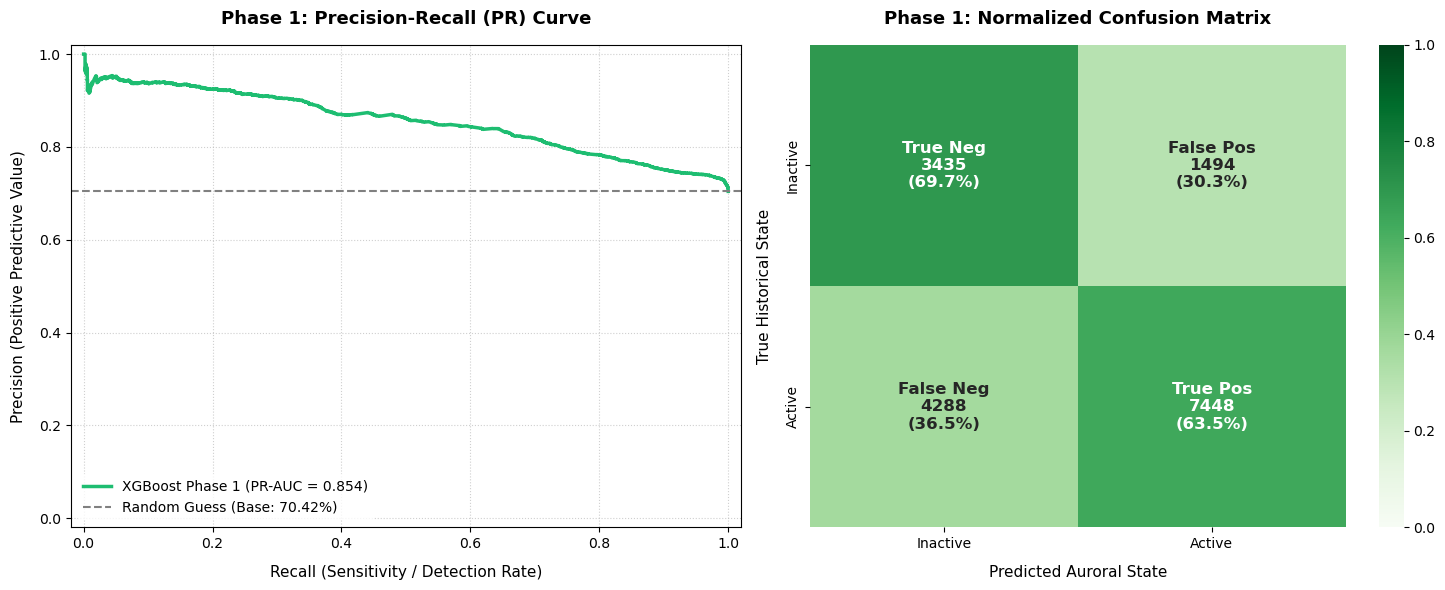

In [233]:
y1_true = df_p2['is_aurora_active'].astype(int)
y1_probs = df_p2['p_activity']
y_preds = df_p2['thresholded_activity_pred'].astype(int)

precisions, recalls, _ = precision_recall_curve(y1_true, y1_probs)
pr_auc = average_precision_score(y1_true, y1_probs)
baseline_ratio = y1_true.sum() / len(y1_true) # The proportion of positive cases

cm = confusion_matrix(y1_true, y_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PR Curve 
axes[0].plot(recalls, precisions, color='#1ebd71', lw=2.5, label=f'XGBoost Phase 1 (PR-AUC = {pr_auc:.3f})')
axes[0].axhline(y=baseline_ratio, color='gray', lw=1.5, linestyle='--', label=f'Random Guess (Base: {baseline_ratio:.2%})')
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])
axes[0].set_xlabel('Recall (Sensitivity / Detection Rate)', fontsize=11, labelpad=10)
axes[0].set_ylabel('Precision (Positive Predictive Value)', fontsize=11, labelpad=10)
axes[0].set_title('Phase 1: Precision-Recall (PR) Curve', fontsize=13, weight='bold', pad=15)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')

# Confusion Matrix Heatmap
labels = np.array([
    [f"True Neg\n{cm[0,0]}\n({cm_normalized[0,0]:.1%})", f"False Pos\n{cm[0,1]}\n({cm_normalized[0,1]:.1%})"],
    [f"False Neg\n{cm[1,0]}\n({cm_normalized[1,0]:.1%})", f"True Pos\n{cm[1,1]}\n({cm_normalized[1,1]:.1%})"]
])

sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Greens", cbar=True,
            xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'],
            vmin=0, vmax=1, ax=axes[1], annot_kws={"size": 12, "weight": "bold"})

axes[1].set_xlabel('Predicted Auroral State', fontsize=11, labelpad=10)
axes[1].set_ylabel('True Historical State', fontsize=11, labelpad=10)
axes[1].set_title('Phase 1: Normalized Confusion Matrix', fontsize=13, weight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join("output", "phase1_pr_curve_confusion_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()

$II$. **Probability of Aurora Sighting**

In [234]:
features_phase2 = ['p_activity', 'cloud_cover', 'astronomical_dark_localtime', 'lunar_sky_glare']

## strip out rows with missing data or missing Phase 1 probability estimates
valid_p2_mask = df_p2['p_activity'].notna() & df_p2[features_phase2 + ['is_aurora_seen']].notna().all(axis=1)
df_p2 = df_p2[valid_p2_mask].reset_index(drop=True)

tscv_p2 = TimeSeriesSplit(n_splits=5)
p_seen = np.full(len(df_p2), np.nan)
final_preds2 = np.full(len(df_p2), np.nan)
# valid_test_indices2 = []

for fold, (train_idx, test_idx) in enumerate(tscv_p2.split(df_p2), 1):
    # re-split train data (80% train, 20% val)
    val_size = int(len(train_idx) * 0.2)
    if val_size < 15:
        val_size = min(15, len(train_idx) // 2)
    train_tr_idx = train_idx[:-val_size]
    train_val_idx = train_idx[-val_size:]
    
    X2_train_tr = df_p2.iloc[train_tr_idx][features_phase2]
    y2_train_tr = df_p2.iloc[train_tr_idx]['is_aurora_seen']
    
    X2_train_val = df_p2.iloc[train_val_idx][features_phase2]
    y2_train_val = df_p2.iloc[train_val_idx]['is_aurora_seen']
    
    X2_test = df_p2.iloc[test_idx][features_phase2]
    y2_test = df_p2.iloc[test_idx]['is_aurora_seen']
       
    # Compute scale weight to penalizes mistakes on sparse 'False' observations
    y2_train_full = df_p2.iloc[train_idx]['is_aurora_seen']
    num_neg = np.sum(y2_train_full == 0)  
    num_pos = np.sum(y2_train_full == 1)  
    imbalance_ratio = num_neg / max(1, num_pos)
    
    # Train the model
    model_xgb2 = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.01, random_state=123,
                                scale_pos_weight=imbalance_ratio,
                                early_stopping_rounds=10, eval_metric='logloss')
    model_xgb2.fit(X2_train_tr, y2_train_tr, eval_set=[(X2_train_val, y2_train_val)], verbose=False)
    
    # Extract probabilities from the out-of-sample validation set and the test set
    val_probs = model_xgb2.predict_proba(X2_train_val)[:, 1]
    test_probs = model_xgb2.predict_proba(X2_test)[:, 1]
    
    p_seen[test_idx] = test_probs
    
    # generates cutoffs between the lowest and highest predicted probabilities on the validation set
    if val_probs.min() == val_probs.max():
        candidate_thresholds = [0.5]
    else:
        candidate_thresholds = np.linspace(max(0.1, val_probs.min()), min(0.9, val_probs.max()), 100)
        
    fold_best_threshold = 0.5  
    best_weighted_score = -1
    sensitivity_factor = 1.5
    
    # Evaluate candidate thresholds to find the one that maximizes the weighted score
    for t in candidate_thresholds:
        val_preds_t = (val_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y2_train_val, val_preds_t).ravel()
        
        tpr = tp / max(1, (tp + fn))  
        tnr = tn / max(1, (tn + fp))  
        
        ## amplifying the reward for finding true positive cases, even if it causes a few more false alarms
        weighted_score = (sensitivity_factor * tpr) * tnr
        
        if weighted_score > best_weighted_score:
            best_weighted_score = weighted_score
            fold_best_threshold = t
        
    # use the optimized threshold
    fold_preds = (test_probs >= fold_best_threshold).astype(int)
    final_preds2[test_idx] = fold_preds
    
    cm_normalized = confusion_matrix(y2_test, fold_preds, normalize='true') * 100    
    
    print(f"\n--- Fold {fold} (Threshold Derived From Validation Window: {fold_best_threshold:.4f}) ---")
    print(classification_report(y2_test, fold_preds, zero_division=0))
    print(f"TN: {cm_normalized[0,0]:.2f}% | FP: {cm_normalized[0,1]:.2f}%")
    print(f"FN: {cm_normalized[1,0]:.2f}% | TP: {cm_normalized[1,1]:.2f}%")

df_p2['p_seen'] = p_seen
df_p2['thresholded_seen_pred'] = final_preds2
df_final = df_p2.dropna(subset=['p_seen']).reset_index(drop=True).copy()


--- Fold 1 (Threshold Derived From Validation Window: 0.6397) ---
              precision    recall  f1-score   support

           0       0.33      0.67      0.45       734
           1       0.81      0.52      0.63      2043

    accuracy                           0.56      2777
   macro avg       0.57      0.59      0.54      2777
weighted avg       0.69      0.56      0.58      2777

TN: 67.17% | FP: 32.83%
FN: 48.21% | TP: 51.79%

--- Fold 2 (Threshold Derived From Validation Window: 0.4531) ---
              precision    recall  f1-score   support

           0       0.52      0.49      0.50       897
           1       0.76      0.78      0.77      1880

    accuracy                           0.69      2777
   macro avg       0.64      0.63      0.64      2777
weighted avg       0.68      0.69      0.68      2777

TN: 48.83% | FP: 51.17%
FN: 21.91% | TP: 78.09%

--- Fold 3 (Threshold Derived From Validation Window: 0.5828) ---
              precision    recall  f1-score   sup

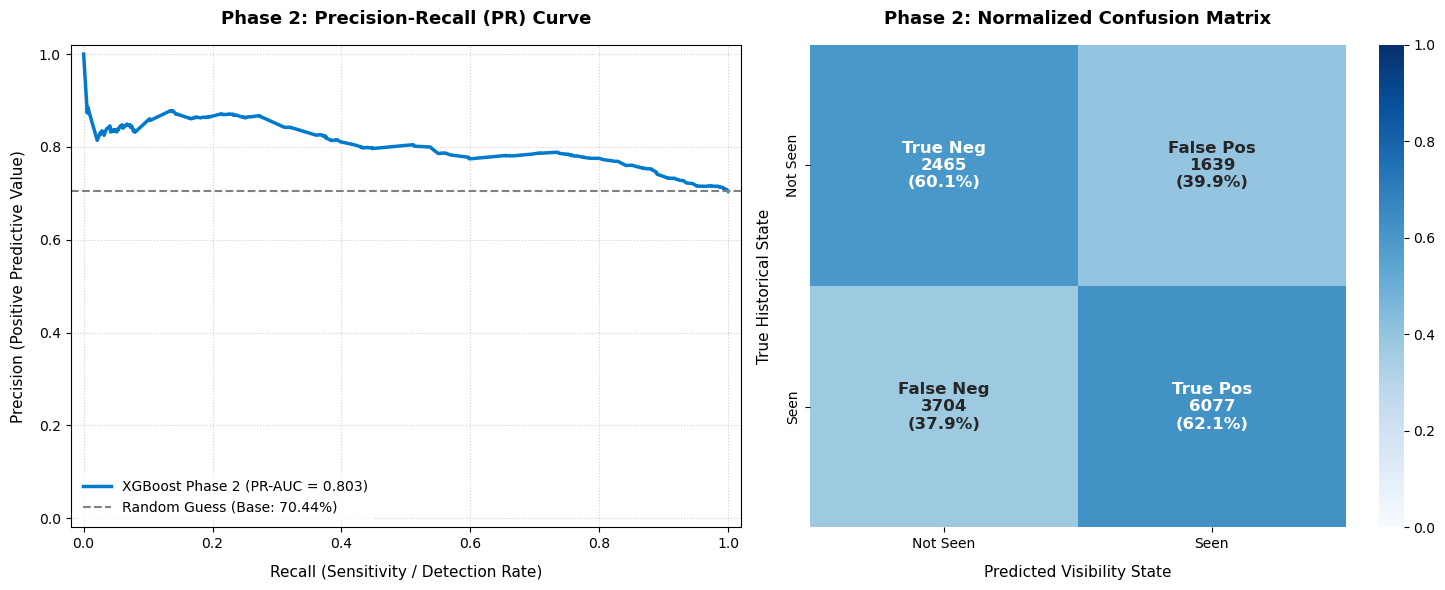

In [235]:
y2_true = df_final['is_aurora_seen'].astype(int)
y2_probs = df_final['p_seen']
y2_preds = df_final['thresholded_seen_pred'].astype(int)

precisions2, recalls2, _ = precision_recall_curve(y2_true, y2_probs)
pr_auc2 = average_precision_score(y2_true, y2_probs)
baseline_ratio2 = y2_true.sum() / len(y2_true)

cm2 = confusion_matrix(y2_true, y2_preds)
cm_normalized2 = cm2.astype('float') / cm2.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

## PR Curve
axes[0].plot(recalls2, precisions2, color='#007acc', lw=2.5, label=f'XGBoost Phase 2 (PR-AUC = {pr_auc2:.3f})')
axes[0].axhline(y=baseline_ratio2, color='gray', lw=1.5, linestyle='--', label=f'Random Guess (Base: {baseline_ratio2:.2%})')
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])
axes[0].set_xlabel('Recall (Sensitivity / Detection Rate)', fontsize=11, labelpad=10)
axes[0].set_ylabel('Precision (Positive Predictive Value)', fontsize=11, labelpad=10)
axes[0].set_title('Phase 2: Precision-Recall (PR) Curve', fontsize=13, weight='bold', pad=15)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')

## confusion Matrix
labels2 = np.array([
    [f"True Neg\n{cm2[0,0]}\n({cm_normalized2[0,0]:.1%})", f"False Pos\n{cm2[0,1]}\n({cm_normalized2[0,1]:.1%})"],
    [f"False Neg\n{cm2[1,0]}\n({cm_normalized2[1,0]:.1%})", f"True Pos\n{cm2[1,1]}\n({cm_normalized2[1,1]:.1%})"]
])

sns.heatmap(cm_normalized2, annot=labels2, fmt="", cmap="Blues", cbar=True,
            xticklabels=['Not Seen', 'Seen'], yticklabels=['Not Seen', 'Seen'],
            vmin=0, vmax=1, ax=axes[1], annot_kws={"size": 12, "weight": "bold"})

axes[1].set_xlabel('Predicted Visibility State', fontsize=11, labelpad=10)
axes[1].set_ylabel('True Historical State', fontsize=11, labelpad=10)
axes[1].set_title('Phase 2: Normalized Confusion Matrix', fontsize=13, weight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join("output", "phase2_pr_curve_confusion_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()

In [236]:
# cross-tabulation of Phase 1 vs Phase 2 final classifications
conditional_matrix = pd.crosstab(
    df_final['thresholded_activity_pred'], 
    df_final['thresholded_seen_pred'],
    margins=True
)

print("=== Chained Pipeline Prediction Alignment Matrix ===")
print(conditional_matrix)

=== Chained Pipeline Prediction Alignment Matrix ===
thresholded_seen_pred       0.0   1.0    All
thresholded_activity_pred                   
0.0                        5009  1572   6581
1.0                        1160  6144   7304
All                        6169  7716  13885


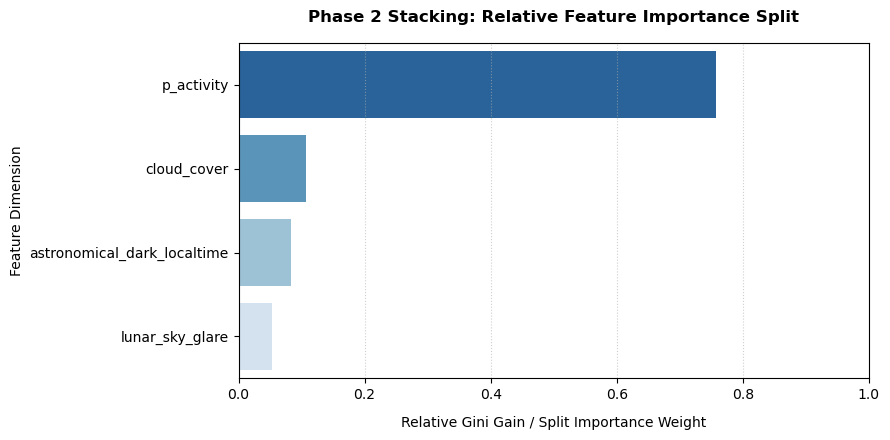


--- Structural Feature Contribution Matrix ---
                    Feature  Importance
                 p_activity    0.756906
                cloud_cover    0.107181
astronomical_dark_localtime    0.083299
            lunar_sky_glare    0.052613


In [237]:
# Extract raw importance metrics from the last trained booster state
importances = model_xgb2.feature_importances_

df_importance = pd.DataFrame({
    'Feature': features_phase2,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 4.5), dpi=100)
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_importance, 
    palette='Blues_r', 
    hue='Feature', 
    legend=False
)

plt.title('Phase 2 Stacking: Relative Feature Importance Split', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Relative Gini Gain / Split Importance Weight', fontsize=10, labelpad=10)
plt.ylabel('Feature Dimension', fontsize=10)
plt.xlim(0, 1.0)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join("output", "phase2_feature_importance.png"), dpi=300, bbox_inches='tight')
plt.show()

# 4. Print clean console telemetry
print("\n--- Structural Feature Contribution Matrix ---")
print(df_importance.to_string(index=False))


**Final Bayesian probability scores**

In [238]:
### save models after final full-dataset training pass
model_xgb1.get_booster().save_model("models/aurora_physics_m1.json")
model_xgb2.get_booster().save_model("models/aurora_atmosphere_m2.json")
## load models
model_phase_1 = XGBClassifier()
model_phase_2 = XGBClassifier()
model_phase_1.load_model("models/aurora_physics_m1.json")
model_phase_2.load_model("models/aurora_atmosphere_m2.json")

def predict_batch_aurora(df_solar_input, df_weather_input):
    """
    Computes real-time localized aurora sighting probabilities for entire DataFrames.
    """
    global model_phase_1, model_phase_2
    
    ## features engineering for Phase 1
    X1 = df_solar_input.copy()
    if 'mlt' in X1.columns:
        X1['mlt_sin'] = np.sin(2 * np.pi * X1['mlt'] / 24.0)
        X1['mlt_cos'] = np.cos(2 * np.pi * X1['mlt'] / 24.0)
    if 'mlon' in X1.columns:
        X1['mlon_sin'] = np.sin(2 * np.pi * X1['mlon'] / 360.0)
        X1['mlon_cos'] = np.cos(2 * np.pi * X1['mlon'] / 360.0)
        
    features_p1 = ['mlat', 'mlon_sin', 'mlon_cos', 'mlt_sin', 'mlt_cos', 'kp', 'bz_gsm', 'sigma_bz_gsm', 'solar_wind_speed']
    X1_final = X1[features_p1]
    
    ## Generate Phase 1 predictions
    p_activity = model_phase_1.predict_proba(X1_final)[:, 1]
    
    ## features engineering for Phase 2
    X2 = df_weather_input.copy()
    X2['p_activity'] = p_activity
    
    if 'moon_phase' in X2.columns and 'moon_darkness' in X2.columns:
        X2['lunar_sky_glare'] = X2['moon_phase'] * (1.0 - X2['moon_darkness'])
        
    features_p2 = ['p_activity', 'cloud_cover', 'astronomical_dark_localtime', 'lunar_sky_glare']
    X2_final = X2[features_p2]
    
    # Generate Phase 2 predictions P(Seen | Activity, Environment)
    p_seen = model_phase_2.predict_proba(X2_final)[:, 1]
    
    df_results = pd.DataFrame({
        'prob_activity_overhead': p_activity,
        'final_sighting_probability': p_seen
    }, index=df_solar_input.index)
    
    return df_results

In [239]:
# def display_jupyter_aurora_map_clean(df_eval, max_display_points=500):
#     """
#     Generates a single world map of predictions inline with safe point sampling.
#     """
#     # Safeguard: Downsample if the matrix is too massive for a smooth browser render
#     if len(df_eval) > max_display_points:
#         print(f"Sampling {max_display_points} points from {len(df_eval)} total rows to preserve browser RAM...")
#         df_plot = df_eval.sample(n=max_display_points, random_state=42).copy()
#     else:
#         df_plot = df_eval.copy()

#     # Initialize map with horizontal structural boundaries 
#     m = folium.Map(
#         location=[60.0, -10.0], 
#         zoom_start=2,
#         min_zoom=2,
#         max_zoom=10,
#         world_copy_jump=False,
#         max_bounds=True
#     )
    
#     # Apply explicit NO-WRAP tile configuration
#     folium.TileLayer(
#         tiles="CartoDB positron", 
#         no_wrap=True
#     ).add_to(m)
    
#     marker_cluster = MarkerCluster().add_to(m)
    
#     for idx, row in df_plot.iterrows():
#         lat, lon = row['latitude'], row['longitude']
#         y_true = int(row['is_aurora_seen'])
#         y_pred = int(row['thresholded_seen_pred'])
#         p_val = row['p_seen']
        
#         ## classification categories
#         if y_true == 1 and y_pred == 1:
#             color, label = '#1ebd71', '🟢 True Positive (Seen)'
#         elif y_true == 0 and y_pred == 0:
#             color, label = '#007acc', '🔵 True Negative (Not Seen)'
#         elif y_true == 0 and y_pred == 1:
#             color, label = '#e74c3c', '🔴 False Positive (False Alarm)'
#         else:
#             color, label = '#f39c12', '🟠 False Negative (Missed)'
            
#         popup_text = f"""
#         <div style="font-family: Arial, sans-serif; min-width: 200px; font-size: 12px;">
#             <h4 style="margin: 0 0 5px 0; color: {color}; font-size: 14px;">{label}</h4>
#             <hr style="margin: 5px 0; border: 0; border-top: 1px solid #ccc;">
#             <b>Probability:</b> {p_val:.2%}<br>
#             <b>Cloud Cover:</b> {row['cloud_cover']}%<br>
#             <b>Magnetic Lat (mlat):</b> {row['mlat']:.2f}<br>
#             <b>Wind Speed:</b> {row['solar_wind_speed']:.0f} km/s
#         </div>
#         """
        
#         folium.Marker(
#             location=[lat, lon],
#             icon=folium.plugins.BeautifyIcon(
#                 icon_shape='circle-dot',
#                 border_color=color,
#                 background_color=color,
#                 border_width=1
#             ),
#             popup=folium.Popup(popup_text, max_width=300)
#         ).add_to(marker_cluster)
        
#     return m

# # Save the map safely
# final_aurora_map = display_jupyter_aurora_map_clean(df_final)
# final_aurora_map.save(os.path.join("output", "aurora_prediction_map.html"))
# # Display inline inside Jupyter Notebook
# final_aurora_map


In [240]:
def display_jupyter_aurora_map_clean(df_eval, max_display_points=500, grid_resolution=0.5):
    """
    Generates a single world map fit into the window boundaries displaying the aurora predictions.
       
    Parameters:
    - df_eval: DataFrame containing latitude, longitude, and prediction targets.
    - max_display_points: safety limit for total display markers.
    - grid_resolution: Float. The cell size in degrees. Larger values mean points 
                      must be physically further apart to be displayed.
    """
    df_working = df_eval.copy()
    
    # Spatial Bin coordinates into a localized geographic grid
    df_working['lat_grid'] = (df_working['latitude'] / grid_resolution).round() * grid_resolution
    df_working['lon_grid'] = (df_working['longitude'] / grid_resolution).round() * grid_resolution
    
    # Keep only the first record inside each coordinate cell block to remove close points
    df_plot = df_working.drop_duplicates(subset=['lat_grid', 'lon_grid']).copy()
    print(f"Spatial thinning reduced rows from {len(df_eval)} to {len(df_plot)} distant locations.")
    
    # sample down to protect browser RAM
    if len(df_plot) > max_display_points:
        print(f"Applying final random sample fallback down to {max_display_points} points...")
        df_plot = df_plot.sample(n=max_display_points, random_state=42)

    # World Bounds
    world_bounds = [[-85.0, -180.0], [85.0, 180.0]]
    center_lat = df_plot['latitude'].mean() if not df_plot.empty else 60.0
    center_lon = df_plot['longitude'].mean() if not df_plot.empty else -10.0

    # Initialize map completely optimized to fit within the viewport window
    m = folium.Map(
        location=[center_lat, center_lon], 
        zoom_start=2,               # Global view zoom
        min_zoom=2,                 # Prevents zooming out into empty gray space
        max_zoom=10,
        world_copy_jump=False,      # Prevents infinite horizontal wrapping loops
        no_wrap=True,               # Cuts map off cleanly at international date line
        max_bounds=True             # Locks camera panning inside world limits
    )
    
    m.fit_bounds(world_bounds)
    
    # Apply NO-WRAP tile configuration
    folium.TileLayer(
        tiles="CartoDB positron", 
        no_wrap=True
    ).add_to(m)
    
    for idx, row in df_plot.iterrows():
        lat, lon = row['latitude'], row['longitude']
        y_true = int(row['is_aurora_seen'])
        y_pred = int(row['thresholded_seen_pred'])
        p_val = row['p_seen']
        
        # Classification error profile categories
        if y_true == 1 and y_pred == 1:
            color, label = '#1ebd71', '🟢 True Positive (Seen)'
        elif y_true == 0 and y_pred == 0:
            color, label = '#007acc', '🔵 True Negative (Not Seen)'
        elif y_true == 0 and y_pred == 1:
            color, label = '#e74c3c', '🔴 False Positive (False Alarm)'
        else:
            color, label = '#f39c12', '🟠 False Negative (Missed)'
            
        popup_text = f"""
        <div style="font-family: Arial, sans-serif; min-width: 200px; font-size: 12px;">
            <h4 style="margin: 0 0 5px 0; color: {color}; font-size: 14px;">{label}</h4>
            <hr style="margin: 5px 0; border: 0; border-top: 1px solid #ccc;">
            <b>Probability:</b> {p_val:.2%}<br>
            <b>Cloud Cover:</b> {row['cloud_cover']}%<br>
            <b>Magnetic Lat (mlat):</b> {row['mlat']:.2f}<br>
            <b>Wind Speed:</b> {row['solar_wind_speed']:.0f} km/s
        </div>
        """
        
        
        # Render dynamic-sized micro-dots with a sharp white isolating border
        dynamic_radius = 1.5 + (p_val * 5.0)
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=float(dynamic_radius),       # Dynamic size maps directly to likelihood percentage
            color='#ffffff',                  # White edge line isolates close neighbors
            weight=0.5,                         # Ultra-thin border line width
            fill=True,
            fill_color=color,                   # Categorical target hex color
            fill_opacity=0.90,                  # Keeps tiny dots dense and colorful
            popup=folium.Popup(popup_text, max_width=300)
        ).add_to(m)
        
    return m

final_aurora_map = display_jupyter_aurora_map_clean(df_final)

os.makedirs("output", exist_ok=True)
html_output_filename = os.path.join("output", "aurora_prediction_map.html")
final_aurora_map.save(html_output_filename)
print(f"Map successfully rendered and compiled to {html_output_filename}")

final_aurora_map

Spatial thinning reduced rows from 13885 to 2889 distant locations.
Applying final random sample fallback down to 500 points...
Map successfully rendered and compiled to output/aurora_prediction_map.html
